In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset
from src.misc import load_config
from src.predict import load_predict_config, load_predictor


In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"
SAMPLE_COUNT = 4
AXES = ("axis 0", "axis 1", "axis 2")

In [3]:
cfg = load_predict_config(PREDICT_CONFIG)
run = ROOT / cfg.run_dir
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = load_predictor(run, device=dev)
opts = cfg.make_options(pred)

data = Namespace(**load_config(run / "model.yaml"))
data.data_dir = {
    axis: (path if (path := Path(value)).is_absolute() else run / path).resolve()
    for axis, value in data.data_dir.items()
}
data.augment = False
ds = build_dataset(data)
real = []
gen = []
for axis in range(3):
    pool = ds.condition_indices[axis]
    pick = torch.randint(len(pool), (SAMPLE_COUNT,)).tolist()
    real.append(torch.stack([ds[pool[i]][0][0] for i in pick]))
    gen.append(
        pred.predict_images(
            axis,
            SAMPLE_COUNT,
            phase_fractions=opts.phase_fractions,
            ddim_steps=opts.ddim_steps,
            guidance_scale=opts.guidance_scale,
            progress=False,
        )
    )
real = torch.stack(real)
gen = torch.stack(gen)
count = torch.bincount(gen.flatten().long(), minlength=pred.num_phases)
fracs = [round(v, 4) for v in (count / count.sum()).tolist()]
print(f"run={run.name} fractions={fracs}")

run=20260718-124524-421219 fractions=[0.4788, 0.1373, 0.3839]


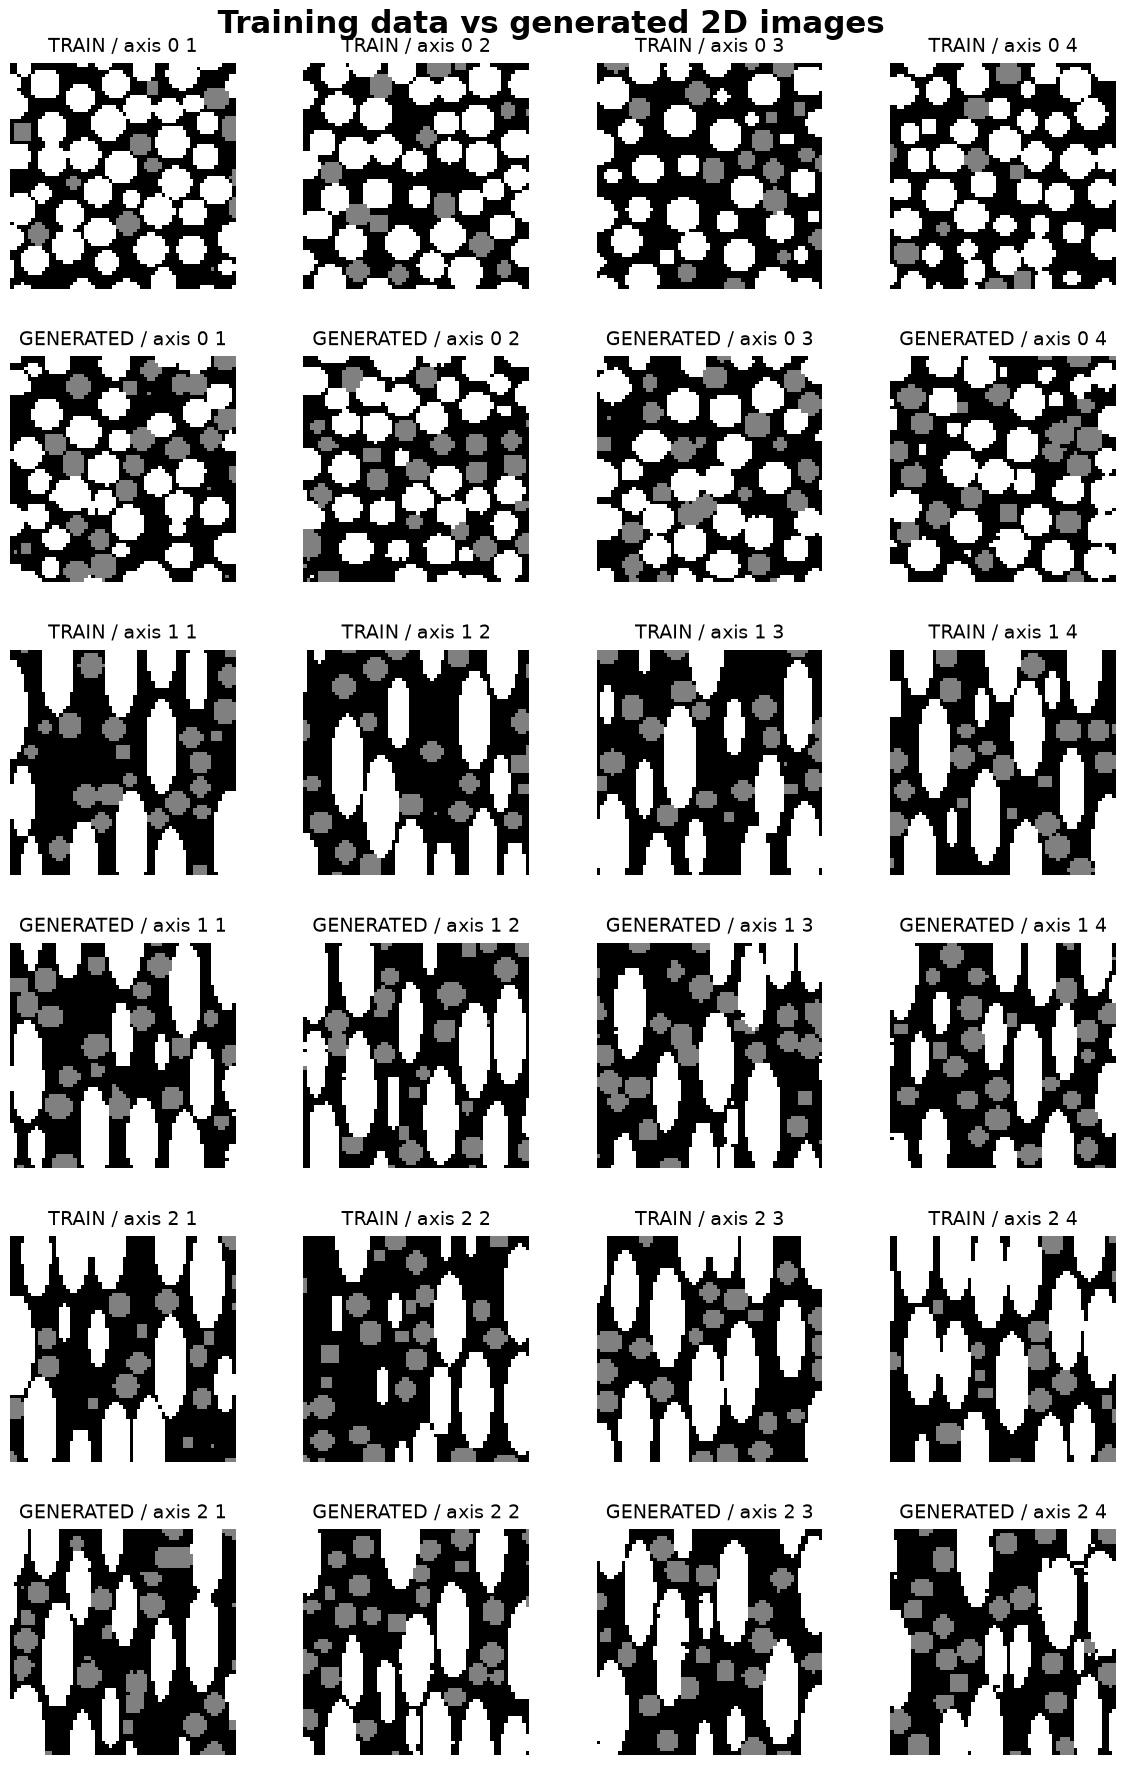

In [4]:
fig, axs = plt.subplots(
    6, SAMPLE_COUNT, figsize=(3 * SAMPLE_COUNT, 18), squeeze=False
)
for axis in range(3):
    rows = (
        (real[axis], f"TRAIN / {AXES[axis]}"),
        (gen[axis], f"GENERATED / {AXES[axis]}"),
    )
    for pos, (imgs, title) in enumerate(rows):
        row = axis * 2 + pos
        for col, (ax, img) in enumerate(zip(axs[row], imgs)):
            ax.imshow(
                img,
                cmap="gray",
                vmin=0,
                vmax=pred.num_phases - 1,
                interpolation="nearest",
            )
            ax.set_title(f"{title} {col + 1}", fontsize=14, pad=8)
            ax.axis("off")
fig.suptitle(
    "Training data vs generated 2D images", fontsize=22, fontweight="bold", y=0.99
)
fig.subplots_adjust(left=0.03, right=0.99, bottom=0.02, top=0.96, wspace=0.08, hspace=0.30)
plt.show()